# How to use external MatGL and MACE models to select structures from a `pool_set`

## What you need to change

For the MatGL demo, set `pool_set` and choose a `matgl:` model spec such as
`matgl:TensorNet-PES-MatPES-PBE-2025.2-m`.

For the full MACE selection at the end, the notebook uses an official MACE foundation-model URL by default, so it can run even when no local MACE checkpoint has been downloaded. You can replace `mace_model_url` with another official `.model` URL if needed.


In [1]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
repo_root = cwd if (cwd / 'curator').is_dir() else cwd.parent
notebook_dir = repo_root / 'notebooks'
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

# Change only this path.
pool_set = repo_root / 'example' / 'LiFePO4.traj'
assert pool_set.exists(), f'pool_set does not exist: {pool_set}'

run_dir = notebook_dir / 'runs' / 'matgl_tensornet_2025_2_m_select_demo'
run_dir.mkdir(parents=True, exist_ok=True)

pool_set, run_dir


(PosixPath('/home/xinyang/curator/example/LiFePO4.traj'),
 PosixPath('/home/xinyang/curator/notebooks/runs/matgl_tensornet_2025_2_m_select_demo'))

## Imports

`load_models(...)` is the key entry point.
When CURATOR sees a string that starts with `matgl:`, it loads the MatGL model and wraps it in a CURATOR-compatible adapter.


In [2]:
import inspect
import json
import os

import h5py
import matplotlib.pyplot as plt
import numpy as np
import torch

from ase.io import read, write
from pytorch_lightning import seed_everything
from umap import UMAP

from curator.layer._feature import FeatureExtractor
from curator.layer.utils import find_layer_by_name_recursive
from curator.select import GeneralActiveLearning
from curator.utils import load_models

os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')
seed_everything(123, workers=True)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
device


Failed to get GPU information from pynvml: Not Supported. Using default values.


GPU information: NVIDIA RTX A6000, 8, 6, 45, 84, 300, 2100


Seed set to 123


'cuda'

## 1. Load the MatGL model

This is the exact idea used by `curator-select`:

- pass a `model_path` string,
- let `load_models(...)` decide how to load it,
- get back a CURATOR model object.

For a MatGL model, the returned object is a `MatGLAdapter`, not the raw MatGL model.


In [3]:
model = load_models(
    'matgl:TensorNet-PES-MatPES-PBE-2025.2-m',
    device=device,
    load_compiled=False,
)[0]

{
    'loaded_object': model.__class__.__name__,
    'wrapped_core_model': model.core_model.__class__.__name__,
    'backend': model.backend,
    'cutoff': model.representation.cutoff,
    'device': device,
    'load_models_source': inspect.getfile(load_models),
    'adapter_source': inspect.getfile(model.__class__),
}


/home/xinyang/miniconda3/lib/python3.13/site-packages/torch_geometric/llm/utils/backend_utils.py:26: DeprecationWarning: `torch_geometric.distributed` has been deprecated since 2.7.0 and will no longer be maintained. For distributed training, refer to our tutorials on distributed training at https://pytorch-geometric.readthedocs.io/en/latest/tutorial/distributed.html or cuGraph examples at https://github.com/rapidsai/cugraph-gnn/tree/main/python/cugraph-pyg/cugraph_pyg/examples
  from torch_geometric.distributed import (


Warp 1.12.0 initialized:
   CUDA Toolkit 12.9, Driver 13.1
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA RTX PRO 4000 Blackwell" (24 GiB, sm_120, mempool enabled)
   Kernel cache:
     /home/xinyang/.cache/warp/1.12.0


{'loaded_object': 'MatGLAdapter',
 'wrapped_core_model': 'TensorNet',
 'backend': 'PYG',
 'cutoff': 5.0,
 'device': 'cuda',
 'load_models_source': '/home/xinyang/curator/curator/utils.py',
 'adapter_source': '/home/xinyang/curator/curator/model/adapter/matgl.py'}

## 2. Check the target layer used by selection

For this TensorNet example, selection uses `target_layer='final_layer'`.

That matters because `FeatureExtractor` will attach hooks under this module and collect the features and gradients used by the selection kernel.


In [4]:
target_layer = 'final_layer'
target_module = find_layer_by_name_recursive(model, target_layer)
linear_types = FeatureExtractor._resolve_linear_types()
linear_modules = [
    (name, child.__class__.__name__)
    for name, child in target_module.named_modules()
    if isinstance(child, linear_types)
]

print('target layer name:', target_layer)
print('resolved module class:', target_module.__class__.__name__)
print('number of linear-like submodules:', len(linear_modules))
linear_modules[:8]


target layer name: final_layer
resolved module class: WeightedReadOut
number of linear-like submodules: 8


[('gated.layers.0', 'Linear'),
 ('gated.layers.2', 'Linear'),
 ('gated.layers.4', 'Linear'),
 ('gated.layers.6', 'Linear'),
 ('gated.gates.0', 'Linear'),
 ('gated.gates.2', 'Linear'),
 ('gated.gates.4', 'Linear'),
 ('gated.gates.6', 'Linear')]

## 3. See how one structure from `pool_set` becomes a MatGL graph

`MatGLAdapter` converts ASE atoms into the graph objects expected by MatGL.
This is the bridge between CURATOR's dataset pipeline and the MatGL model.


In [5]:
atoms = read(pool_set, index=0)
graph, lat, state_attr = model.graph_converter.get_graph(atoms)

num_nodes = graph.num_nodes if not callable(getattr(graph, 'num_nodes', None)) else graph.num_nodes()
try:
    num_edges = graph.num_edges if not callable(getattr(graph, 'num_edges', None)) else graph.num_edges()
except Exception:
    num_edges = int(graph.edge_index.shape[1])

{
    'formula': atoms.get_chemical_formula(),
    'num_atoms': len(atoms),
    'pbc': tuple(bool(x) for x in atoms.pbc),
    'graph_class': graph.__class__.__name__,
    'graph_nodes': num_nodes,
    'graph_edges': num_edges,
    'lat_shape': tuple(lat.shape),
    'state_attr_shape': tuple(state_attr.shape),
}


{'formula': 'Fe4Li4O16P4',
 'num_atoms': 28,
 'pbc': (True, True, True),
 'graph_class': 'Data',
 'graph_nodes': 28,
 'graph_edges': 1112,
 'lat_shape': (1, 3, 3),
 'state_attr_shape': (2,)}

## 4. Build the active-learning object

This object is what actually drives structure selection.

Important arguments here:

- `models=[model]`: use the MatGL TensorNet adapter
- `feature_specs=[{'preset': 'fg-sketch'}]`: use sketched full-gradient features
- `selection_feature='fg-sketch'`: select with that exported feature block
- `selection='lcmd_greedy'`: use LCMD greedy selection
- `target_layer='final_layer'`: extract features from TensorNet's final readout layer
- `save_features=...`: store the features so they can be visualized later


In [6]:
features_h5 = run_dir / 'features.h5'
feature_specs = [
    {
        'preset': 'fg-sketch',
        'num_features': 256,
        'seed': 123,
    }
]
selection_feature = 'fg-sketch'

al = GeneralActiveLearning(
    models=[model],
    selection='lcmd_greedy',
    feature_specs=feature_specs,
    selection_feature=selection_feature,
    target_layer='final_layer',
    batch_size=4,
    device=device,
    dataset_cutoff=model.representation.cutoff,
    transforms=[],
    save_features=str(features_h5),
    target_domain=None,
)

{
    'selection_engine': al.__class__.__name__,
    'selection_engine_source': inspect.getfile(GeneralActiveLearning),
    'feature_specs': feature_specs,
    'selection_feature': al.selection_feature,
    'selection_method': al.selection,
    'target_layer': al.target_layer,
    'batch_size': al.batch_size,
    'dataset_cutoff': al.dataset_cutoff,
    'features_h5': str(features_h5),
}


{'selection_engine': 'GeneralActiveLearning',
 'selection_engine_source': '/home/xinyang/curator/curator/select/active_learning.py',
 'feature_specs': [{'preset': 'fg-sketch', 'num_features': 256, 'seed': 123}],
 'selection_feature': 'fg-sketch',
 'selection_method': 'lcmd_greedy',
 'target_layer': 'final_layer',
 'batch_size': 4,
 'dataset_cutoff': 5.0,
 'features_h5': '/home/xinyang/curator/notebooks/runs/matgl_tensornet_2025_2_m_select_demo/features.h5'}

## 5. Select structures from `pool_set`

This is the core call.

If your `pool_set` is large, this may take some time. For a first test, you can lower `select_batch_size`.
The selected indices are written to `selected.json`.


In [7]:
selected = al.select(
    pool_set=str(pool_set),
    train_set=None,
    select_batch_size=100,
    save_json=str(run_dir / 'selected.json'),
    save_images=None,
    save_selected_features=None,
    normalize_features=True,
    compute_features_only=False,
)

print('number of selected structures:', len(selected))
print('first ten selected indices:', selected[:10])


model=MatGLAdapter kernels=1 size=2257 bs=4:   0%|          | 0/565 [00:00<?, ?it/s]

number of selected structures: 100
first ten selected indices: [1841, 1899, 1214, 2213, 1822, 1671, 1951, 1446, 1883, 1588]


In [8]:
json.loads((run_dir / 'selected.json').read_text())


{'kernel': 'fg-sketch',
 'selection': 'lcmd_greedy',
 'dataset': {'pool': '/home/xinyang/curator/example/LiFePO4.traj',
  'train': None},
 'selected': [1841,
  1899,
  1214,
  2213,
  1822,
  1671,
  1951,
  1446,
  1883,
  1588,
  2118,
  1055,
  1868,
  882,
  1759,
  265,
  2154,
  2192,
  919,
  2235,
  2034,
  1856,
  520,
  1624,
  481,
  1891,
  2081,
  1421,
  1018,
  195,
  1924,
  1232,
  1286,
  2130,
  2250,
  1981,
  1108,
  2045,
  1785,
  635,
  2164,
  2061,
  1129,
  1812,
  1366,
  1262,
  1409,
  420,
  1549,
  1476,
  1570,
  1539,
  1799,
  945,
  769,
  1942,
  617,
  1737,
  726,
  2202,
  344,
  2096,
  550,
  1141,
  1966,
  453,
  738,
  2004,
  1314,
  1657,
  1093,
  1394,
  359,
  2025,
  1727,
  48,
  2067,
  1294,
  756,
  654,
  1598,
  1196,
  496,
  1578,
  2180,
  849,
  1349,
  1494,
  1243,
  90,
  1513,
  183,
  1161,
  1462,
  823,
  588,
  141,
  966,
  1607,
  1906],
 'summary': {'count': 100,
  'filter_enabled': False,
  'pool_size_before': 225

## 6. Visualize the selection in UMAP space

The plotting logic below is adapted from:
`/home/xinyang/curator/runs/select_matgl_compare/plot_selection_umap_with_aef.py`

The idea is:

1. load the saved `fg-sketch` features from `features.h5`,
2. reduce them to 2D with UMAP,
3. overlay the CURATOR `lcmd_greedy` selection,
4. build a simple baseline that selects the structures with the largest AE-F,
5. compare both selections on the same figure,
6. if reference forces are available in `pool_set`, color the background by AE-F
   (mean absolute force error).

AE-F needs reference forces inside the structures in `pool_set`.
If they are not available, the notebook will still make a UMAP plot, but the
`max AE-F` comparison will not be available.


In [9]:
def read_selected(path: Path) -> np.ndarray:
    with path.open('r', encoding='utf-8') as handle:
        return np.asarray(json.load(handle)['selected'], dtype=int)


def has_reference_forces(path: Path) -> bool:
    sample = read(path, index=0)
    try:
        sample.get_forces(apply_constraint=False)
        return True
    except Exception:
        return False


def compute_aef_from_adapter(model, pool_set: Path, batch_size: int = 8) -> np.ndarray:
    atoms_list = read(str(pool_set), ':')
    aef = np.zeros((len(atoms_list),), dtype=np.float64)

    for start in range(0, len(atoms_list), batch_size):
        batch = atoms_list[start : start + batch_size]
        n_atoms = [len(atoms) for atoms in batch]
        g, lat, state = model._batch_graphs(batch)
        g = g.to(device)
        lat = lat.to(device)
        state = state.to(device)

        out = model.potential(g=g, lat=lat, state_attr=state)
        if not isinstance(out, tuple) or len(out) < 2:
            raise RuntimeError('MatGL potential output does not include force predictions.')
        force_pred = out[1].detach().cpu().numpy()

        offset = 0
        for i, atoms in enumerate(batch):
            n = n_atoms[i]
            fp = force_pred[offset : offset + n]
            ft = atoms.get_forces(apply_constraint=False)
            aef[start + i] = float(np.mean(np.abs(fp - ft)))
            offset += n

    return aef


def compute_aef_from_curator_model(model, pool_set: Path, batch_size: int = 4) -> np.ndarray:
    from curator.data import AseDataset, properties
    from curator.data.utils import iter_batches

    dataset = AseDataset(str(pool_set), cutoff=model.representation.cutoff)
    model_device = next(model.parameters()).device
    model_dtype = next(model.parameters()).dtype
    aef = np.zeros((len(dataset),), dtype=np.float64)
    image_offset = 0
    was_training = model.training
    model.eval()

    for batch in iter_batches(
        dataset=dataset,
        batch_size=batch_size,
        device=model_device,
        dtype=model_dtype,
        desc=f'AE-F model={model.__class__.__name__} size={len(dataset)} bs={batch_size}',
    ):
        target_forces = batch[properties.forces].detach().cpu().numpy()
        predicted = model(batch)[properties.forces].detach().cpu().numpy()
        counts = batch[properties.n_atoms].detach().cpu().view(-1).tolist()

        atom_offset = 0
        for n_atoms in counts:
            n_atoms = int(n_atoms)
            fp = predicted[atom_offset : atom_offset + n_atoms]
            ft = target_forces[atom_offset : atom_offset + n_atoms]
            aef[image_offset] = float(np.mean(np.abs(fp - ft)))
            image_offset += 1
            atom_offset += n_atoms

    if was_training:
        model.train()
    return aef


In [10]:
feature_key = 'fg-sketch'
lcmd_idx = read_selected(run_dir / 'selected.json')

with h5py.File(features_h5, 'r') as handle:
    features = handle[f'features/{feature_key}/data'][0]

embedding = UMAP(
    n_components=2,
    n_neighbors=30,
    min_dist=0.12,
    metric='cosine',
    random_state=42,
).fit_transform(features)

aef = None
max_aef_idx = None
overlap_idx = None
only_lcmd_idx = None
only_aef_idx = None
if has_reference_forces(pool_set):
    aef = compute_aef_from_adapter(model, pool_set=pool_set, batch_size=8)
    max_aef_idx = np.argsort(aef)[-len(lcmd_idx):]
    lcmd_set = set(lcmd_idx.tolist())
    max_aef_set = set(max_aef_idx.tolist())
    overlap_idx = np.array(sorted(lcmd_set & max_aef_set), dtype=int)
    only_lcmd_idx = np.array(sorted(lcmd_set - max_aef_set), dtype=int)
    only_aef_idx = np.array(sorted(max_aef_set - lcmd_set), dtype=int)

print('features shape:', features.shape)
print('embedding shape:', embedding.shape)
print('has AE-F:', aef is not None)
if aef is not None:
    print('LCMD count:', len(lcmd_idx))
    print('max-AE-F count:', len(max_aef_idx))
    print('overlap count:', len(overlap_idx))


/home/xinyang/miniconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/home/xinyang/miniconda3/lib/python3.13/contextlib.py:145: ResourceWarning: unclosed file <_io.BufferedReader name='/home/xinyang/curator/example/LiFePO4.traj'>
  def __exit__(self, typ, value, traceback):


Module matgl.kernels.graph_transform 24eb07e load on device 'cuda:0' took 1.06 ms  (cached)
Module radial_message_passing_fwd_float32 0984349 load on device 'cuda:0' took 0.79 ms  (cached)
Module compose_tensor_float32 dff4c9a load on device 'cuda:0' took 0.89 ms  (cached)
Module decompose_tensor_float32 f530c49 load on device 'cuda:0' took 0.93 ms  (cached)
Module message_passing_fwd_float32 79c071c load on device 'cuda:0' took 0.53 ms  (cached)
Module tensor_matmul_o3_3x3_float32 82bd05a load on device 'cuda:0' took 0.57 ms  (cached)
Module tensor_matmul_so3_3x3_float32 674c3f9 load on device 'cuda:0' took 0.57 ms  (cached)
Module tensor_norm3_fwd_float32 3d6c389 load on device 'cuda:0' took 0.62 ms  (cached)
Module tensor_norm3_bwd_float32 7770518 load on device 'cuda:0' took 0.85 ms  (cached)
Module tensor_matmul_so3_3x3_bwd_float32 8b51f8a load on device 'cuda:0' took 0.85 ms  (cached)


/home/xinyang/miniconda3/lib/python3.13/site-packages/torch/nn/modules/module.py:1864: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


Module compose_tensor_bwd_float32 f06ebd8 load on device 'cuda:0' took 1.29 ms  (cached)
Module decompose_tensor_bwd_float32 790a560 load on device 'cuda:0' took 1.12 ms  (cached)
Module tensor_matmul_o3_3x3_bwd_float32 40582a9 load on device 'cuda:0' took 0.97 ms  (cached)
Module message_passing_bwd_float32 0ca69ce load on device 'cuda:0' took 0.72 ms  (cached)
Module radial_message_passing_bwd_float32 0e4712a load on device 'cuda:0' took 0.80 ms  (cached)


features shape: (2257, 2048)
embedding shape: (2257, 2)
has AE-F: True
LCMD count: 100
max-AE-F count: 100
overlap count: 8


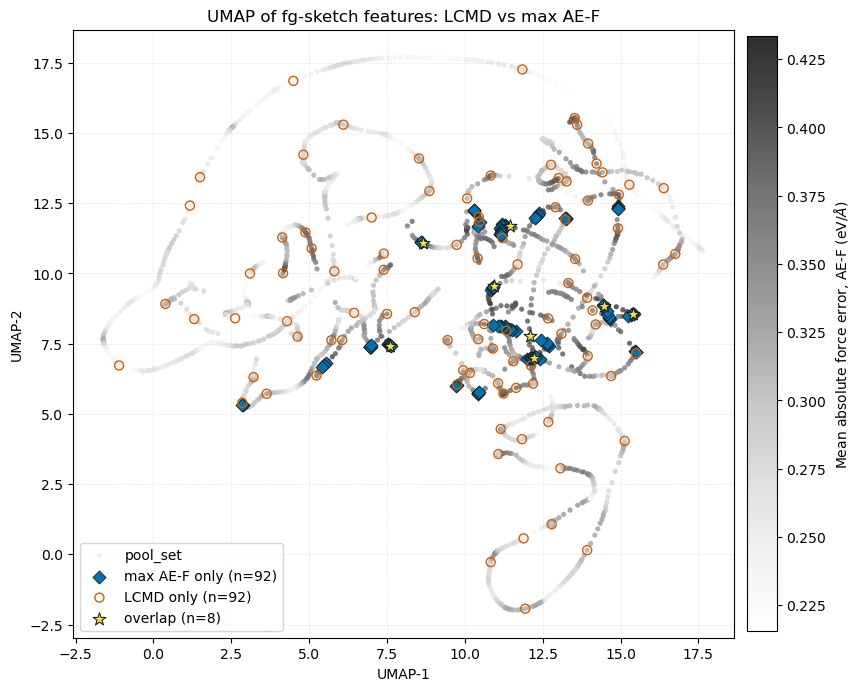

saved: /home/xinyang/curator/notebooks/runs/matgl_tensornet_2025_2_m_select_demo/umap_lcmd_vs_max_aef.png
saved: /home/xinyang/curator/notebooks/runs/matgl_tensornet_2025_2_m_select_demo/umap_lcmd_vs_max_aef.pdf


In [11]:
fig, ax = plt.subplots(figsize=(8.5, 6.8), constrained_layout=True)

color_lcmd_only = '#D55E00'
color_max_aef_only = '#0072B2'
color_overlap = '#F0E442'
color_edge = '#1A1A1A'

if aef is None:
    ax.scatter(
        embedding[:, 0],
        embedding[:, 1],
        s=14,
        c='#B8BDC7',
        alpha=0.65,
        linewidths=0,
        rasterized=True,
        label='pool_set',
    )
else:
    vmin = float(np.percentile(aef, 1.0))
    vmax = float(max(np.percentile(aef, 99.0), vmin + 1e-12))
    sc = ax.scatter(
        embedding[:, 0],
        embedding[:, 1],
        c=aef,
        cmap='Greys',
        s=14,
        alpha=0.82,
        linewidths=0,
        vmin=vmin,
        vmax=vmax,
        rasterized=True,
        label='pool_set',
    )
    cbar = fig.colorbar(sc, ax=ax, pad=0.02, fraction=0.045)
    cbar.set_label(r'Mean absolute force error, AE-F (eV/$\AA$)')

if aef is None:
    ax.scatter(
        embedding[lcmd_idx, 0],
        embedding[lcmd_idx, 1],
        s=42,
        facecolors='none',
        edgecolors=color_lcmd_only,
        linewidths=1.0,
        marker='o',
        zorder=5,
        label=f'LCMD selected (n={len(lcmd_idx)})',
    )
    ax.set_title('UMAP of fg-sketch features with LCMD selection')
else:
    if len(only_aef_idx) > 0:
        ax.scatter(
            embedding[only_aef_idx, 0],
            embedding[only_aef_idx, 1],
            s=44,
            c=color_max_aef_only,
            edgecolors=color_edge,
            linewidths=0.6,
            marker='D',
            zorder=5,
            label=f'max AE-F only (n={len(only_aef_idx)})',
        )
    if len(only_lcmd_idx) > 0:
        ax.scatter(
            embedding[only_lcmd_idx, 0],
            embedding[only_lcmd_idx, 1],
            s=42,
            facecolors='none',
            edgecolors=color_lcmd_only,
            linewidths=1.0,
            marker='o',
            zorder=6,
            label=f'LCMD only (n={len(only_lcmd_idx)})',
        )
    if len(overlap_idx) > 0:
        ax.scatter(
            embedding[overlap_idx, 0],
            embedding[overlap_idx, 1],
            s=95,
            c=color_overlap,
            edgecolors=color_edge,
            linewidths=0.75,
            marker='*',
            zorder=7,
            label=f'overlap (n={len(overlap_idx)})',
        )
    ax.set_title('UMAP of fg-sketch features: LCMD vs max AE-F')

ax.set_xlabel('UMAP-1')
ax.set_ylabel('UMAP-2')
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.3)
ax.legend(loc='best')

plot_png = run_dir / 'umap_lcmd_vs_max_aef.png'
plot_pdf = run_dir / 'umap_lcmd_vs_max_aef.pdf'
fig.savefig(plot_png, dpi=300, bbox_inches='tight')
fig.savefig(plot_pdf, dpi=300, bbox_inches='tight')
plt.show()

print('saved:', plot_png)
print('saved:', plot_pdf)


## 7. A complete `curator-select` YAML config for a MatGL model

If you do not want to build `GeneralActiveLearning(...)` manually in Python, you can do the same job with a normal `curator-select` YAML file.

This is the complete config pattern you need for MatGL TensorNet selection.


In [12]:
yaml_text = f"""_convert_: all
cfg: null
seed: 123
run_path: {run_dir}
model_path: matgl:TensorNet-PES-MatPES-PBE-2025.2-m
device: {device}
train_set: null
pool_set: {pool_set}
data_url: null
data_batch_size: 4
select_batch_size: 100
method: lcmd_greedy
selection_feature: fg-sketch
feature_specs:
  - preset: fg-sketch
    num_features: 256
    seed: 123
target_layer: final_layer
save_features: true
save_selected_features: null
export_normalized_features: true
save_images: false
compute_features_only: false
target_domain: null
transforms: []
"""

print(yaml_text)


_convert_: all
cfg: null
seed: 123
run_path: /home/xinyang/curator/notebooks/runs/matgl_tensornet_2025_2_m_select_demo
model_path: matgl:TensorNet-PES-MatPES-PBE-2025.2-m
device: cuda
train_set: null
pool_set: /home/xinyang/curator/example/LiFePO4.traj
data_url: null
data_batch_size: 4
select_batch_size: 100
method: lcmd_greedy
selection_feature: fg-sketch
feature_specs:
  - preset: fg-sketch
    num_features: 256
    seed: 123
target_layer: final_layer
save_features: true
save_selected_features: null
export_normalized_features: true
save_images: false
compute_features_only: false
target_domain: null
transforms: []



In [13]:
yaml_path = run_dir / 'select_matgl_tensornet_2025_2_m.yaml'
yaml_path.write_text(yaml_text, encoding='utf-8')

print('saved:', yaml_path)
print()
print('Run this from a shell:')
print(f'curator-select cfg={yaml_path}')


saved: /home/xinyang/curator/notebooks/runs/matgl_tensornet_2025_2_m_select_demo/select_matgl_tensornet_2025_2_m.yaml

Run this from a shell:
curator-select cfg=/home/xinyang/curator/notebooks/runs/matgl_tensornet_2025_2_m_select_demo/select_matgl_tensornet_2025_2_m.yaml


That YAML is enough to use a MatGL model for pool selection in CURATOR.

The two most important lines are:

- `model_path: matgl:TensorNet-PES-MatPES-PBE-2025.2-m`
- `target_layer: final_layer`

The first tells CURATOR to load an external MatGL model through the adapter.
The second tells CURATOR where to attach hooks for feature extraction.


## 8. Run a full official MACE runtime selection

This section uses the same full `pool_set` as the MatGL example and loads an official MACE checkpoint directly through `mace:...?runtime=official`. It runs a complete CURATOR active-learning selection with `fg-sketch` features and `lcmd_greedy`, then writes `selected.json` and `features.h5` under the notebook run directory.


In [14]:
mace_model_url = 'https://huggingface.co/mace-foundations/mace-mp-0/resolve/main/mace-mp-0b3-medium.model'
mace_model_spec = f'mace:{mace_model_url}?runtime=official'
mace_run_dir = notebook_dir / 'runs' / 'mace_official_full_select'
mace_run_dir.mkdir(parents=True, exist_ok=True)

mace_device = device
mace_result = {
    'mace_model_url': mace_model_url,
    'mace_model_spec': mace_model_spec,
    'pool_set': str(pool_set),
}

mace_model = load_models(
    mace_model_spec,
    device=mace_device,
    load_compiled=False,
)[0]
mace_features_h5 = mace_run_dir / 'features.h5'
mace_al = GeneralActiveLearning(
    models=[mace_model],
    selection='lcmd_greedy',
    feature_specs=[
        {
            'preset': 'fg-sketch',
            'num_features': 256,
            'seed': 123,
        }
    ],
    selection_feature='fg-sketch',
    target_layer='readout_mlp',
    batch_size=4,
    device=mace_device,
    dataset_cutoff=mace_model.representation.cutoff,
    transforms=[],
    save_features=str(mace_features_h5),
    target_domain=None,
)
mace_selected = mace_al.select(
    pool_set=str(pool_set),
    train_set=None,
    select_batch_size=100,
    save_json=str(mace_run_dir / 'selected.json'),
    save_images=None,
    save_selected_features=None,
    normalize_features=True,
    compute_features_only=False,
)
mace_result.update(
    {
        'loaded_object': mace_model.__class__.__name__,
        'core_model': mace_model.model.__class__.__name__,
        'cutoff': mace_model.representation.cutoff,
        'target_layer': mace_al.target_layer,
        'selection': mace_al.selection,
        'selection_feature': mace_al.selection_feature,
        'select_batch_size': 100,
        'selected_count': len(mace_selected),
        'first_ten_selected': mace_selected[:10],
        'features_h5': str(mace_features_h5),
        'selected_json': str(mace_run_dir / 'selected.json'),
    }
)

mace_result


/home/xinyang/miniconda3/lib/python3.13/site-packages/openequivariance/__init__.py:38: UserWarning: PyTorch version 2.8.0+cu128 is < 2.10, minimum required for precompiled extension. Please upgrade to 2.10.
Precompiled extension shared object not found.
For these reasons, falling back to JIT compilation of OpenEquivariance extension, which may hang. If waiting for >5 minutes, clear ~/.cache/torch_extensions or address the conditions above.

  from openequivariance._torch.TensorProduct import TensorProduct


model=MACEAdapter kernels=1 size=2257 bs=4:   0%|          | 0/565 [00:00<?, ?it/s]

{'mace_model_url': 'https://huggingface.co/mace-foundations/mace-mp-0/resolve/main/mace-mp-0b3-medium.model',
 'mace_model_spec': 'mace:https://huggingface.co/mace-foundations/mace-mp-0/resolve/main/mace-mp-0b3-medium.model?runtime=official',
 'pool_set': '/home/xinyang/curator/example/LiFePO4.traj',
 'loaded_object': 'MACEAdapter',
 'core_model': 'ScaleShiftMACE',
 'cutoff': 6.0,
 'target_layer': 'readout_mlp',
 'selection': 'lcmd_greedy',
 'selection_feature': 'fg-sketch',
 'select_batch_size': 100,
 'selected_count': 100,
 'first_ten_selected': [1841,
  2078,
  935,
  1958,
  2093,
  284,
  2140,
  1877,
  1793,
  472],
 'features_h5': '/home/xinyang/curator/notebooks/runs/mace_official_full_select/features.h5',
 'selected_json': '/home/xinyang/curator/notebooks/runs/mace_official_full_select/selected.json'}

## 9. Visualize the full MACE selection

This plot mirrors the MatGL visualization above: it embeds the MACE `fg-sketch` features, colors the pool by MACE AE-F, and compares the MACE `lcmd_greedy` selection with the structures that have the largest MACE AE-F.


/home/xinyang/miniconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


AE-F model=MACEAdapter size=2257 bs=4:   0%|          | 0/565 [00:00<?, ?it/s]

/home/xinyang/miniconda3/lib/python3.13/site-packages/torch/nn/modules/module.py:1864: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


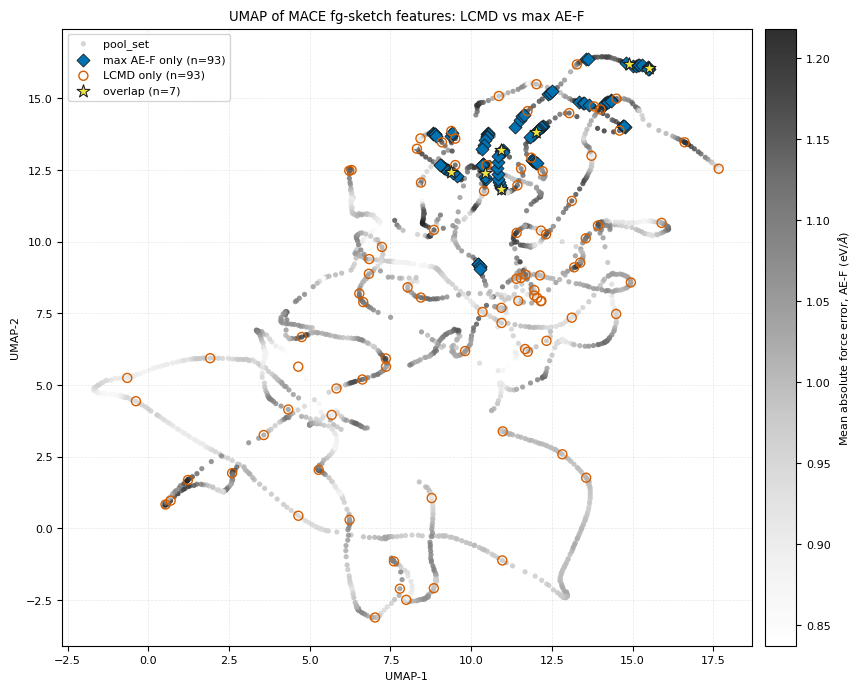

mace features shape: (2257, 768)
mace embedding shape: (2257, 2)
has AE-F: True
LCMD count: 100
max-AE-F count: 100
overlap count: 7
saved: /home/xinyang/curator/notebooks/runs/mace_official_full_select/umap_lcmd_vs_max_aef.png
saved: /home/xinyang/curator/notebooks/runs/mace_official_full_select/umap_lcmd_vs_max_aef.pdf


In [15]:
mace_feature_key = 'fg-sketch'
mace_lcmd_idx = read_selected(mace_run_dir / 'selected.json')

with h5py.File(mace_features_h5, 'r') as handle:
    mace_features = handle[f'features/{mace_feature_key}/data'][0]

mace_embedding = UMAP(
    n_components=2,
    n_neighbors=30,
    min_dist=0.12,
    metric='cosine',
    random_state=42,
).fit_transform(mace_features)

mace_aef = None
mace_max_aef_idx = None
mace_overlap_idx = None
mace_only_lcmd_idx = None
mace_only_aef_idx = None
if has_reference_forces(pool_set):
    mace_aef = compute_aef_from_curator_model(mace_model, pool_set=pool_set, batch_size=4)
    mace_max_aef_idx = np.argsort(mace_aef)[-len(mace_lcmd_idx):]
    mace_lcmd_set = set(mace_lcmd_idx.tolist())
    mace_max_aef_set = set(mace_max_aef_idx.tolist())
    mace_overlap_idx = np.array(sorted(mace_lcmd_set & mace_max_aef_set), dtype=int)
    mace_only_lcmd_idx = np.array(sorted(mace_lcmd_set - mace_max_aef_set), dtype=int)
    mace_only_aef_idx = np.array(sorted(mace_max_aef_set - mace_lcmd_set), dtype=int)

fig, ax = plt.subplots(figsize=(8.5, 6.8), constrained_layout=True)

color_lcmd_only = '#D55E00'
color_max_aef_only = '#0072B2'
color_overlap = '#F0E442'
color_edge = '#1A1A1A'

if mace_aef is None:
    ax.scatter(
        mace_embedding[:, 0],
        mace_embedding[:, 1],
        s=14,
        c='#B8BDC7',
        alpha=0.65,
        linewidths=0,
        rasterized=True,
        label='pool_set',
    )
else:
    vmin = float(np.percentile(mace_aef, 1.0))
    vmax = float(max(np.percentile(mace_aef, 99.0), vmin + 1e-12))
    sc = ax.scatter(
        mace_embedding[:, 0],
        mace_embedding[:, 1],
        c=mace_aef,
        cmap='Greys',
        s=14,
        alpha=0.82,
        linewidths=0,
        vmin=vmin,
        vmax=vmax,
        rasterized=True,
        label='pool_set',
    )
    cbar = fig.colorbar(sc, ax=ax, pad=0.02, fraction=0.045)
    cbar.set_label(r'Mean absolute force error, AE-F (eV/$\AA$)')

if mace_aef is None:
    ax.scatter(
        mace_embedding[mace_lcmd_idx, 0],
        mace_embedding[mace_lcmd_idx, 1],
        s=42,
        facecolors='none',
        edgecolors=color_lcmd_only,
        linewidths=1.0,
        marker='o',
        zorder=5,
        label=f'LCMD selected (n={len(mace_lcmd_idx)})',
    )
    ax.set_title('UMAP of MACE fg-sketch features with LCMD selection')
else:
    if len(mace_only_aef_idx) > 0:
        ax.scatter(
            mace_embedding[mace_only_aef_idx, 0],
            mace_embedding[mace_only_aef_idx, 1],
            s=44,
            c=color_max_aef_only,
            edgecolors=color_edge,
            linewidths=0.6,
            marker='D',
            zorder=5,
            label=f'max AE-F only (n={len(mace_only_aef_idx)})',
        )
    if len(mace_only_lcmd_idx) > 0:
        ax.scatter(
            mace_embedding[mace_only_lcmd_idx, 0],
            mace_embedding[mace_only_lcmd_idx, 1],
            s=42,
            facecolors='none',
            edgecolors=color_lcmd_only,
            linewidths=1.0,
            marker='o',
            zorder=6,
            label=f'LCMD only (n={len(mace_only_lcmd_idx)})',
        )
    if len(mace_overlap_idx) > 0:
        ax.scatter(
            mace_embedding[mace_overlap_idx, 0],
            mace_embedding[mace_overlap_idx, 1],
            s=95,
            c=color_overlap,
            edgecolors=color_edge,
            linewidths=0.75,
            marker='*',
            zorder=7,
            label=f'overlap (n={len(mace_overlap_idx)})',
        )
    ax.set_title('UMAP of MACE fg-sketch features: LCMD vs max AE-F')

ax.set_xlabel('UMAP-1')
ax.set_ylabel('UMAP-2')
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.3)
ax.legend(loc='best')

mace_plot_png = mace_run_dir / 'umap_lcmd_vs_max_aef.png'
mace_plot_pdf = mace_run_dir / 'umap_lcmd_vs_max_aef.pdf'
fig.savefig(mace_plot_png, dpi=300, bbox_inches='tight')
fig.savefig(mace_plot_pdf, bbox_inches='tight')
plt.show()

print('mace features shape:', mace_features.shape)
print('mace embedding shape:', mace_embedding.shape)
print('has AE-F:', mace_aef is not None)
if mace_aef is not None:
    print('LCMD count:', len(mace_lcmd_idx))
    print('max-AE-F count:', len(mace_max_aef_idx))
    print('overlap count:', len(mace_overlap_idx))
print('saved:', mace_plot_png)
print('saved:', mace_plot_pdf)
